In [1]:
import os,sys

# Set the path to the parent directory manually
parent_dir = os.path.abspath("../..")
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
    
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings
import pkg_resources
from datetime import datetime as dt, timedelta
from datetime import datetime
import glob
from netCDF4 import Dataset
from util.wrf_process import (calc_derive, object_tracking, read_and_write, to_polar)
from util.ml_framework import (cnn, vae)
from wrf import (to_np, getvar, smooth2d, get_cartopy, cartopy_xlim,
                 cartopy_ylim, latlon_coords, interplevel, ll_to_xy)
import gc,pickle
from tqdm import tqdm
import xarray as xr
from natsort import natsorted
from util.ml_preprocess import data_preproc
#from vae3d import VAEEncoder, VAEDecoder, VAE, elbo_loss, weights_init
import optuna
import random,math
import proplot as plot

/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/1496010805.py:12: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# --- 1. ProPlot Configuration for Aesthetic ---
# Resetting to ProPlot defaults is good practice, then apply specific styles.
plot.rc.reset() 

# Set global font size, family, and math font
plot.rc.update({
    'font.size': 13.5,          # Matched target aesthetic
    'font.name': 'DejaVu Sans', # A common, clean sans-serif like the target image
    'mathtext.fontset': 'dejavusans', # Match math font to text font
    'grid.alpha': 0.7,        # Make grid lines slightly transparent
    'grid.linewidth': 1.0,    # Thicker grid lines
    'grid.linestyle': '--',   # Dotted/dashed grid
    'grid.color': 'lightgray', # Light grey grid color
    'linewidth': 1.5,         # Default line width for spines and major ticks
    'ticklen': 5,             # Tick length
    'tickdir': 'out',         # Ticks point outward (or 'in' if preferred)
    'axes.spines.right': False, # Remove right spine
    'axes.spines.top': False,   # Remove top spine
    'axes.titlepad': 5.0,     # Adjust title padding if needed
    'legend.framealpha': 1.0,   # Opaque legend background
    'legend.facecolor': 'white',# White legend background
    'legend.edgecolor': '0.8',  # Light gray legend border
    'legend.fontsize': 11,      # Legend font size
    'legend.fancybox': True,    # Rounded corners for legend
# --- White Background Settings ---
    'figure.facecolor': 'white', # Set the color of the canvas/figure outside the axes
    'axes.facecolor': 'white',   # Set the color of the plotting area/axes background
})

/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3751352792.py:6: ProplotWarning: rc setting 'linewidth' was renamed to 'meta.width' in version 0.8.
  plot.rc.update({


In [3]:
def save_to_pickle(filepath,data):
    with open(filepath, 'wb') as handle:
        pickle.dump(data, handle)

def open_pickle(filepath):
    with open(filepath, 'rb') as handle:
        data = pickle.load(handle)
    return data

## Read in files

In [4]:
# Track path
track_memb03 = xr.open_dataset('/glade/work/ihtam/storage/track_avor_850-600.nc')

ctrl_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/ctrl/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan/ctrl/wrfout_d02_2013-11-0*"))[:6]
miaxi2x_files = sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2idealaxi/wrfout_d02_2013-11-0*"))[:24]
aiaxi2x_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2IDEAL/wrfout_d02_2013-11-0*"))[:24] #sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/add_2idealaxi/wrfout_d02_2013-11-0*"))[:6]
mdd_p2f_files =sorted(glob.glob("/glade/campaign/univ/uokl0049/haiyan_pattern/minus_2DDp_pareto2/wrfout_d02_2013-11-0*"))[:24]
dd_p2f_files = sorted(glob.glob("/glade/derecho/scratch/ihtam/haiyan_perturb/add_2ML_pp2/wrfout_d02_2013-11-0*"))[:24]

thetae_dict = open_pickle('./parallel/store/thetae_dict.pkl')
theta_dict = open_pickle('./parallel/store/theta_dict.pkl')
tk_dict = open_pickle('./parallel/store/tk_dict.pkl')
ua_dict = open_pickle('./parallel/store/ua_dict.pkl')
pres_dict = open_pickle('./store/memb03_sen/pres_dict.pkl')
va_dict = open_pickle('./parallel/store/va_dict.pkl')
wa_dict = open_pickle('./parallel/store/wa_dict.pkl')
H_DIABATIC_dict = open_pickle('./parallel/store/H_DIABATIC_dict.pkl')

In [5]:
class PV:
    def __init__(self,ua_dict,va_dict,wa_dict,thetae_dict,tk_dict, pres,z,track,expname):
        self.ua_dict = ua_dict
        self.va_dict = va_dict
        self.wa_dict = wa_dict
        self.thetae_dict = thetae_dict
        self.tk_dict = tk_dict
        self.pres = pres # Pressure levels
        self.z = z # AGL Height levels
        self.track = track # TC track
        self.expname = expname # Name of experiments

        self.pres = pres # Pressure levels
        self.z = z # AGL Height levels
        self.track = track # TC track
        self.expname = expname # Name of experiments

    def cartesian_to_radial_tangential(self, ua, va, az_deg):
        """
        Convert Cartesian wind components (ua, va) on a cylindrical grid
        to radial and tangential wind components.

        Parameters
        ----------
        ua, va : ndarray
            Wind components on cylindrical grid.
            Shape can be (..., naz), e.g. (time, lev, nr, naz)
        az_deg : ndarray
            Azimuth angles in degrees, shape (naz,)
            Assumed mathematical convention:
            0 deg = +x, 90 deg = +y, increasing counterclockwise.

        Returns
        -------
        ur, ut : ndarray
            Radial and tangential wind components, same shape as ua/va.
            ur > 0 is outward
            ut > 0 is counterclockwise
        """
        az_rad = np.deg2rad(az_deg)

        cosaz = np.cos(az_rad)
        sinaz = np.sin(az_rad)

        # reshape for broadcasting onto last dimension
        shape = [1] * ua.ndim
        shape[-1] = len(az_deg)

        cosaz = cosaz.reshape(shape)
        sinaz = sinaz.reshape(shape)

        ur = ua * cosaz + va * sinaz
        ut = -ua * sinaz + va * cosaz

        return ur, ut

    def get_ur_ut(self):
        ur_dict = {}
        ut_dict = {}
        for expnamez in self.expname:
            ur, ut = self.cartesian_to_radial_tangential(ua_dict[expnamez]['varpol'], va_dict[expnamez]['varpol'], ua_dict[expnamez]['az'])
            ur_dict[expnamez] = ur
            ut_dict[expnamez] = ut
        return ur_dict, ut_dict 
        
    def w_to_omega(self, wa, T, p):
        """
        Convert vertical velocity w (m/s) to omega (Pa/s)
    
        Parameters
        ----------
        wa : ndarray
            Vertical velocity (m/s), shape (time, lev, r, az)
        T : ndarray
            Temperature (K), same shape as wa
        p : ndarray
            Pressure levels (Pa), shape (lev,)
    
        Returns
        -------
        omega : ndarray
            Pressure velocity (Pa/s)
        """
        G = 9.80665
        RD = 287.0
        p4 = p[None, :, None, None]
        omega = -(p4 * G / (RD * T)) * wa
        return omega

    def get_omega(self):
        omega_dict = {}
        for expnamez in self.expname:
            omega = self.w_to_omega(wa_dict[expnamez]['varpol'], tk_dict[expnamez]['varpol'], self.pres)
            omega_dict[expnamez] = omega
        return omega_dict

    def compute_full_mpv(self, ur, ut, omega, thetae, r, theta, p):
        """
        Full moist PV in cylindrical coordinates (r, theta, p)
    
        Parameters
        ----------
        ur, ut, omega, thetae : ndarray
            Shape (time, lev, nr, ntheta)
        r : ndarray (nr,) in meters
        theta : ndarray (ntheta,) in radians
        p : ndarray (lev,) in Pa
    
        Returns
        -------
        dict of MPV components
        """
        G = 9.80665
        RD = 287.0
        # --- Broadcast helpers ---
        r4 = r[None, None, :, None]
    
        # --- Gradients of theta_e ---
        dthetae_dr = np.gradient(thetae, r, axis=2)
        dthetae_dtheta = np.gradient(thetae, theta, axis=3)
        dthetae_dp = np.gradient(thetae, p, axis=1)

        # --- Velocity derivatives ---
        dut_dp = np.gradient(ut, p, axis=1)
        dur_dp = np.gradient(ur, p, axis=1)

        domega_dr = np.gradient(omega, r, axis=2)
        domega_dtheta = np.gradient(omega, theta, axis=3)

        dur_dtheta = np.gradient(ur, theta, axis=3)

        # r * ut derivative
        rut = r4 * ut
        drut_dr = np.gradient(rut, r, axis=2)

        # --- Relative vorticity ---
        zeta_r = (1.0 / r4) * domega_dtheta - dut_dp
        zeta_theta = dur_dp - domega_dr
        zeta_p = (1.0 / r4) * drut_dr - (1.0 / r4) * dur_dtheta

        # --- Absolute vorticity ---
        f = 1e-4
        zeta_p_abs = zeta_p + f

        # --- MPV components ---
        mpv_r = -G * zeta_r * dthetae_dr
        mpv_theta = -G * zeta_theta * (1.0 / r4) * dthetae_dtheta
        mpv_p = -G * zeta_p_abs * dthetae_dp
    
        mpv_total = mpv_r + mpv_theta + mpv_p

        return {
            "mpv_total": mpv_total,
            "mpv_r": mpv_r,
            "mpv_theta": mpv_theta,
            "mpv_p": mpv_p,
            "zeta_r": zeta_r,
            "zeta_theta": zeta_theta,
            "zeta_p": zeta_p,
            "dthetae_dr": dthetae_dr,
            "dthetae_dtheta": dthetae_dtheta,
            "dthetae_dp": dthetae_dp
        }

    def get_moistPV(self,ur_dict,ut_dict,omega_dict,thetae_dict,ua_dict):
        moistPV_dict = {}
        for expnamez in (self.expname):
            shape_ur = ur_dict[expnamez].shape[0]
            moistPV = self.compute_full_mpv(ur_dict[expnamez][:shape_ur,...], ut_dict[expnamez][:shape_ur,...], 
                                            omega_dict[expnamez][:shape_ur,...], thetae_dict[expnamez][:shape_ur,...],
                                            ua_dict[expnamez]['r']*1000, np.deg2rad(ua_dict[expnamez]['az']), self.pres)
            moistPV_dict[expnamez] = moistPV
        return moistPV_dict

    def get_dryPV(self,ur_dict,ut_dict,omega_dict,theta_dict,ua_dict):
        dryPV_dict = {}
        for expnamez in tqdm(self.expname):
            shape_ur = ur_dict[expnamez].shape[0]
            dryPV = self.compute_full_mpv(ur_dict[expnamez][:shape_ur,...], ut_dict[expnamez][:shape_ur,...], 
                                            omega_dict[expnamez][:shape_ur,...], theta_dict[expnamez]['varpol'][:shape_ur,...],
                                            ua_dict[expnamez]['r']*1000, np.deg2rad(ua_dict[expnamez]['az']), self.pres)
            dryPV_dict[expnamez] = dryPV
        return dryPV_dict

In [ ]:
pres = np.array([10000,20000,30000,40000,50000,60000,70000,80000,85000,90000,100000])
z = np.array([500,1000,1500,2000,2500,3000,3500,4000,4500,5000,6000,6500,7000,7500,8000,8500,9000,9500,10000])
PV_init = PV(ua_dict,va_dict,wa_dict,thetae_dict,tk_dict,
               pres,z,track_memb03,['CTRL','AIAXI2X','MIAXI2X','DD_P2F','MDD_P2F'])
ur_dict,ut_dict = PV_init.get_ur_ut()
omega_dict = PV_init.get_omega()
moistPV_dict = PV_init.get_moistPV(ur_dict,ut_dict,omega_dict,thetae_dict,ua_dict)
dryPV_dict = PV_init.get_dryPV(ur_dict,ut_dict,omega_dict,theta_dict,ua_dict)

/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3965773389.py:137: RuntimeWarning: divide by zero encountered in divide
  zeta_r = (1.0 / r4) * domega_dtheta - dut_dp
/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3965773389.py:137: RuntimeWarning: invalid value encountered in multiply
  zeta_r = (1.0 / r4) * domega_dtheta - dut_dp
/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3965773389.py:139: RuntimeWarning: divide by zero encountered in divide
  zeta_p = (1.0 / r4) * drut_dr - (1.0 / r4) * dur_dtheta
/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3965773389.py:139: RuntimeWarning: invalid value encountered in subtract
  zeta_p = (1.0 / r4) * drut_dr - (1.0 / r4) * dur_dtheta
/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3965773389.py:146: RuntimeWarning: invalid value encountered in multiply
  mpv_r = -G * zeta_r * dthetae_dr
/glade/derecho/scratch/ihtam/tmp/ipykernel_68395/3965773389.py:147: RuntimeWarning: divide by zero encountered in divide
  mpv_theta = -G * zeta_th

In [17]:
def calc_pressure_weighted(xdata, preslv, layer_pres_bottom=None, layer_pres_top=None):
    """
    Pressure-weighted mean over full column or a specified pressure layer,
    using only existing vertical levels (no interpolation).

    Parameters
    ----------
    xdata : object
        Must have attribute `data` with shape (nlev, ...).
    preslv : array-like
        Pressure levels in hPa or Pa.
    layer_pres_bottom : float, optional
        Bottom of integration layer, in same units as preslv.
        Default is the maximum pressure level.
    layer_pres_top : float, optional
        Top of integration layer, in same units as preslv.
        Default is the minimum pressure level.

    Returns
    -------
    Q_col : ndarray
        Pressure-weighted mean over the requested layer.
    """
    preslv = np.asarray(preslv, dtype=float)
    Q = np.asarray(xdata.data, dtype=float)

    if Q.shape[0] != len(preslv):
        raise ValueError("First dimension of xdata.data must match length of preslv.")

    # Convert to Pa if needed
    p = preslv * 100.0 if np.min(preslv) < 1000 else preslv.copy()

    # Default: full column
    if layer_pres_bottom is None:
        p_bottom = np.max(p)
    else:
        p_bottom = layer_pres_bottom * 100.0 if layer_pres_bottom < 1000 else float(layer_pres_bottom)

    if layer_pres_top is None:
        p_top = np.min(p)
    else:
        p_top = layer_pres_top * 100.0 if layer_pres_top < 1000 else float(layer_pres_top)

    # Ensure bottom > top
    if p_bottom < p_top:
        p_bottom, p_top = p_top, p_bottom

    # Sort if pressure is decreasing
    if np.any(np.diff(p) < 0):
        p = p[::-1]
        Q = Q[::-1, ...]

    # Keep only levels inside requested layer
    mask = (p >= p_top) & (p <= p_bottom)
    p_sub = p[mask]
    Q_sub = Q[mask, ...]

    if len(p_sub) < 2:
        raise ValueError("Need at least two pressure levels inside the requested layer.")

    # Layer thicknesses
    dp = np.diff(p_sub)

    # Mean value in each layer
    Q_layer = 0.5 * (Q_sub[:-1, ...] + Q_sub[1:, ...])

    # Pressure-weighted mean
    Q_col = np.sum(Q_layer * dp[:, None, None], axis=0) / np.sum(dp)

    return Q_col

In [55]:
HIHIHI = [calc_pressure_weighted(dryPV_dict['CTRL']['mpv_p'][i], pres, 1000, 900) for i in range(24)]

/glade/derecho/scratch/ihtam/tmp/ipykernel_18438/713538199.py:65: RuntimeWarning: invalid value encountered in add
  Q_layer = 0.5 * (Q_sub[:-1, ...] + Q_sub[1:, ...])


/glade/derecho/scratch/ihtam/tmp/ipykernel_18438/2916216806.py:20: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


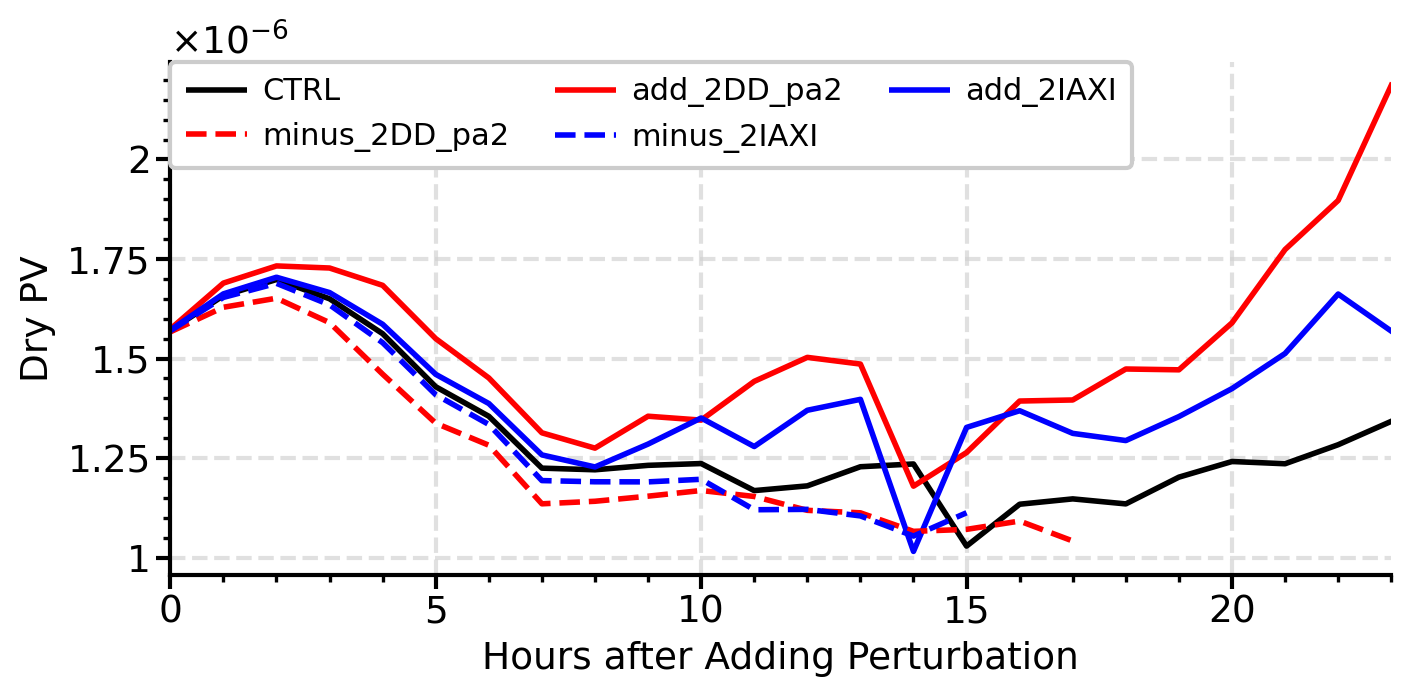

In [71]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
HIHIHI = [calc_pressure_weighted(dryPV_dict['CTRL']['mpv_total'][i], pres, 900,500) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI)[:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
HIHIHI_C = [calc_pressure_weighted(dryPV_dict['DD_P2F']['mpv_total'][i], pres, 900,500) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_C)[:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
HIHIHI_B = [calc_pressure_weighted(dryPV_dict['AIAXI2X']['mpv_total'][i], pres, 900,500) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_B)[:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
HIHIHI_C = [calc_pressure_weighted(dryPV_dict['MDD_P2F']['mpv_total'][i], pres, 900,500) for i in range(18)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_C)[:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
HIHIHI_B = [calc_pressure_weighted(dryPV_dict['MIAXI2X']['mpv_total'][i], pres, 900,500) for i in range(16)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_B)[:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='Dry PV')
plt.tight_layout()
plt.savefig('./pics/dryPV_freetrop_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_18438/2201668816.py:20: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


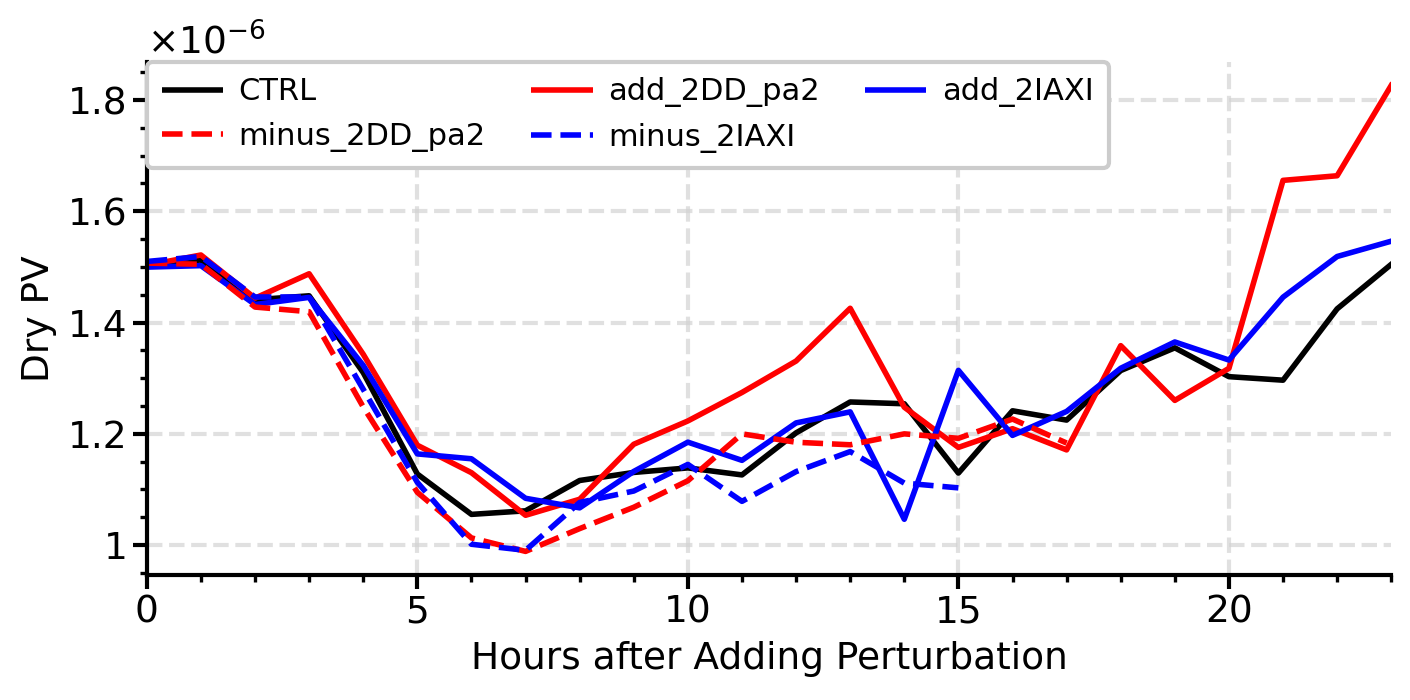

In [72]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
HIHIHI = [calc_pressure_weighted(dryPV_dict['CTRL']['mpv_total'][i], pres, 1000,900) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI)[:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
HIHIHI_C = [calc_pressure_weighted(dryPV_dict['DD_P2F']['mpv_total'][i], pres, 1000,900) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_C)[:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
HIHIHI_B = [calc_pressure_weighted(dryPV_dict['AIAXI2X']['mpv_total'][i], pres, 1000,900) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_B)[:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
HIHIHI_C = [calc_pressure_weighted(dryPV_dict['MDD_P2F']['mpv_total'][i], pres, 1000,900) for i in range(18)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_C)[:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
HIHIHI_B = [calc_pressure_weighted(dryPV_dict['MIAXI2X']['mpv_total'][i], pres, 1000,900) for i in range(16)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_B)[:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='Dry PV')
plt.tight_layout()
plt.savefig('./pics/dryPV_BL_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_18438/713538199.py:65: RuntimeWarning: invalid value encountered in add
  Q_layer = 0.5 * (Q_sub[:-1, ...] + Q_sub[1:, ...])
/glade/derecho/scratch/ihtam/tmp/ipykernel_18438/713538199.py:65: RuntimeWarning: invalid value encountered in add
  Q_layer = 0.5 * (Q_sub[:-1, ...] + Q_sub[1:, ...])
/glade/derecho/scratch/ihtam/tmp/ipykernel_18438/2271730998.py:20: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


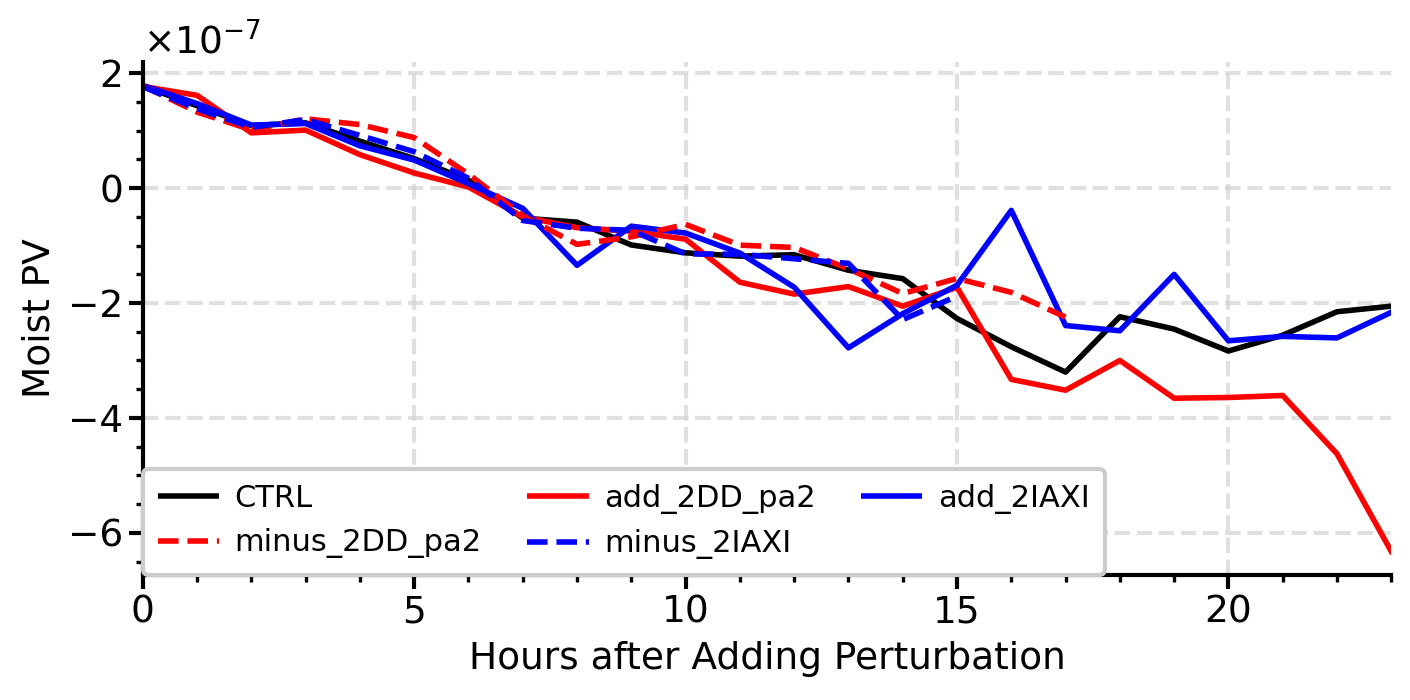

In [69]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
HIHIHI = [calc_pressure_weighted(moistPV_dict['CTRL']['mpv_total'][i], pres, 850,500) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI)[:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
HIHIHI_C = [calc_pressure_weighted(moistPV_dict['DD_P2F']['mpv_total'][i], pres, 850,500) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_C)[:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
HIHIHI_B = [calc_pressure_weighted(moistPV_dict['AIAXI2X']['mpv_total'][i], pres, 850,500) for i in range(24)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_B)[:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
HIHIHI_C = [calc_pressure_weighted(moistPV_dict['MDD_P2F']['mpv_total'][i], pres, 850,500) for i in range(18)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_C)[:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
HIHIHI_B = [calc_pressure_weighted(moistPV_dict['MIAXI2X']['mpv_total'][i], pres, 850,500) for i in range(16)]
am = axs[0].plot(np.nanmean(np.asarray(HIHIHI_B)[:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='Moist PV')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_51645/2834759374.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


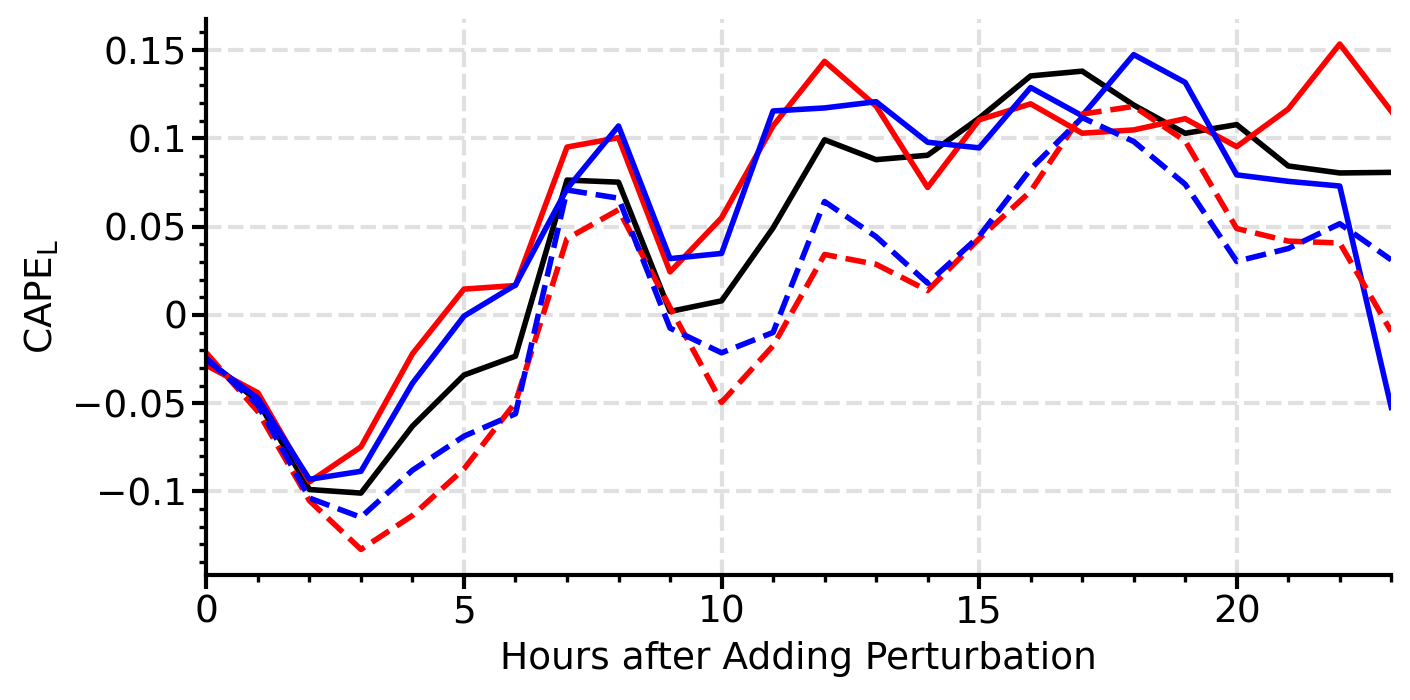

In [11]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
am = axs[0].plot(np.nanmean(capel_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(capel_dict['DD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(capel_dict['AIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(capel_dict['MDD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(capel_dict['MIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
#axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='CAPE$_{L}$')
plt.tight_layout()
plt.savefig('./pics/capel_wrfmemb03.png',dpi=400)
plt.show()

## Read in Diabatic Heating

In [29]:
hdia_pw_dict = buoy_init.get_pressure_weighted(H_DIABATIC_dict,85000,50000)

/glade/derecho/scratch/ihtam/tmp/ipykernel_88006/1596070483.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


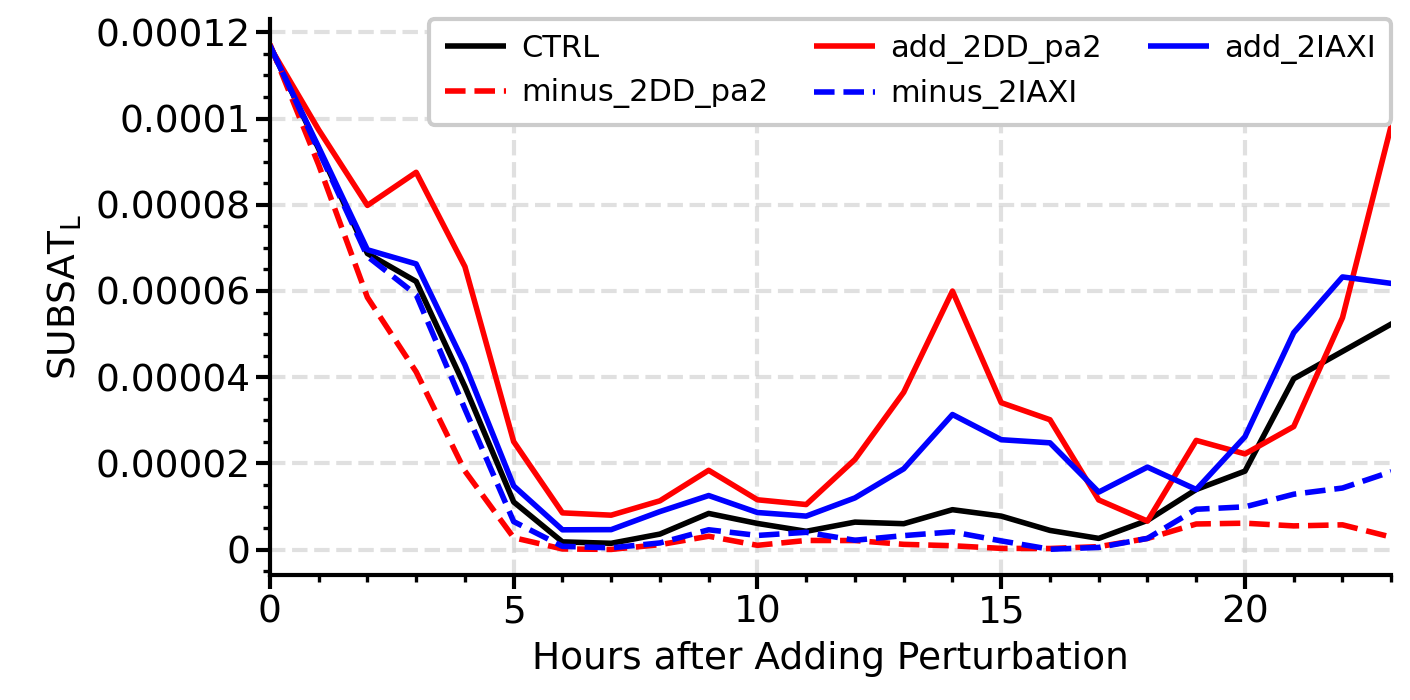

In [30]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
am = axs[0].plot(np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(hdia_pw_dict['DD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(hdia_pw_dict['AIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MDD_P2F'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MIAXI2X'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='SUBSAT$_{L}$')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

In [68]:
def lagged_corr(x, y, max_lag):
    lags = np.arange(-max_lag, max_lag+1)
    corrs = []

    for lag in lags:
        if lag > 0:
            corr = np.corrcoef(x[:-lag], y[lag:])[0,1]
        elif lag < 0:
            corr = np.corrcoef(x[-lag:], y[:lag])[0,1]
        else:
            corr = np.corrcoef(x, y)[0,1]
        corrs.append(corr)

    return lags, np.array(corrs)

lags, lagcorrs = [],[]
for expname in ['AIAXI2X','MIAXI2X','DD_P2F','MDD_P2F']:
    subsat = np.nanmean(subsatl_dict[expname][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2))
    hdia = np.nanmean(hdia_pw_dict[expname][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2))
    lag,corr = lagged_corr(subsat, hdia, 4)
    lags.append(lag)
    lagcorrs.append(corr)

In [53]:
import numpy as np
import pandas as pd
from statsmodels.tsa.stattools import grangercausalitytests, adfuller

def make_stationary(x, method="diff"):
    x = np.asarray(x, dtype=float)
    
    if method == "diff":
        return np.diff(x)
    elif method == "detrend":
        t = np.arange(len(x))
        p = np.polyfit(t, x, 1)
        trend = np.polyval(p, t)
        return x - trend
    elif method == "none":
        return x
    else:
        raise ValueError("method must be 'diff', 'detrend', or 'none'")

def adf_check(x, name="series"):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    result = adfuller(x, autolag="AIC")
    print(f"{name}: ADF p-value = {result[1]:.4f}")

def run_granger_two_ways(x, y, maxlag=6, verbose=False):
    """
    Returns p-values for both directions:
      y -> x
      x -> y
    """
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) <= maxlag + 5:
        raise ValueError("Time series too short for requested maxlag.")

    # In statsmodels:
    # column 2 Granger-causes column 1
    data_y_to_x = np.column_stack([x, y])  # tests y -> x
    data_x_to_y = np.column_stack([y, x])  # tests x -> y

    res_y_to_x = grangercausalitytests(data_y_to_x, maxlag=maxlag, verbose=verbose)
    res_x_to_y = grangercausalitytests(data_x_to_y, maxlag=maxlag, verbose=verbose)

    pvals_y_to_x = []
    pvals_x_to_y = []

    for lag in range(1, maxlag + 1):
        # ssr_ftest is commonly used
        p_y_to_x = res_y_to_x[lag][0]["ssr_ftest"][1]
        p_x_to_y = res_x_to_y[lag][0]["ssr_ftest"][1]

        pvals_y_to_x.append(p_y_to_x)
        pvals_x_to_y.append(p_x_to_y)

    return np.array(pvals_y_to_x), np.array(pvals_x_to_y)

In [65]:
results = {}

for expname in ['AIAXI2X', 'MIAXI2X', 'DD_P2F', 'MDD_P2F']:
    subsat = np.nanmean(subsatl_dict[expname][:, :33, :], axis=(1, 2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2))
    hdia   = np.nanmean(hdia_pw_dict[expname][:, :33, :], axis=(1, 2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2))

    # Make series more stationary
    subsat_s = make_stationary(subsat, method="diff")
    hdia_s   = make_stationary(hdia, method="diff")

    # Optional: check stationarity
    print(f"\nExperiment: {expname}")
    adf_check(subsat_s, "subsat")
    adf_check(hdia_s, "hdia")

    p_hdia_to_subsat, p_subsat_to_hdia = run_granger_two_ways(
        subsat_s, hdia_s, maxlag=6, verbose=False
    )

    results[expname] = {
        "hdia_to_subsat_pvals": p_hdia_to_subsat,
        "subsat_to_hdia_pvals": p_subsat_to_hdia,
    }

    print("lag | hdia -> subsat | subsat -> hdia")
    for lag in range(1, 7):
        print(
            f"{lag:>3} | "
            f"{p_hdia_to_subsat[lag-1]:.4f}          | "
            f"{p_subsat_to_hdia[lag-1]:.4f}"
        )


Experiment: AIAXI2X
subsat: ADF p-value = 0.9860
hdia: ADF p-value = 0.3106
lag | hdia -> subsat | subsat -> hdia
  1 | 0.9991          | 0.7628
  2 | 0.5848          | 0.4007
  3 | 0.1508          | 0.1485
  4 | 0.3499          | 0.2438
  5 | 0.6500          | 0.1646
  6 | 0.5946          | 0.3049

Experiment: MIAXI2X
subsat: ADF p-value = 0.0000
hdia: ADF p-value = 0.9617
lag | hdia -> subsat | subsat -> hdia
  1 | 0.6458          | 0.0757
  2 | 0.8461          | 0.2563
  3 | 0.4704          | 0.0744
  4 | 0.6913          | 0.2828
  5 | 0.8649          | 0.1016
  6 | 0.7944          | 0.2071

Experiment: DD_P2F
subsat: ADF p-value = 0.0000
hdia: ADF p-value = 0.0000
lag | hdia -> subsat | subsat -> hdia
  1 | 0.5894          | 0.0126
  2 | 0.1426          | 0.0231
  3 | 0.2661          | 0.0033
  4 | 0.1239          | 0.0039
  5 | 0.1055          | 0.0324
  6 | 0.3266          | 0.0833

Experiment: MDD_P2F
subsat: ADF p-value = 0.0009
hdia: ADF p-value = 0.0777
lag | hdia -> subsat 

/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/glade/work/ihtam/miniconda3/envs/myenv/lib/python3.8/site-packages/statsmodels/tsa/stattools.py:1545: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


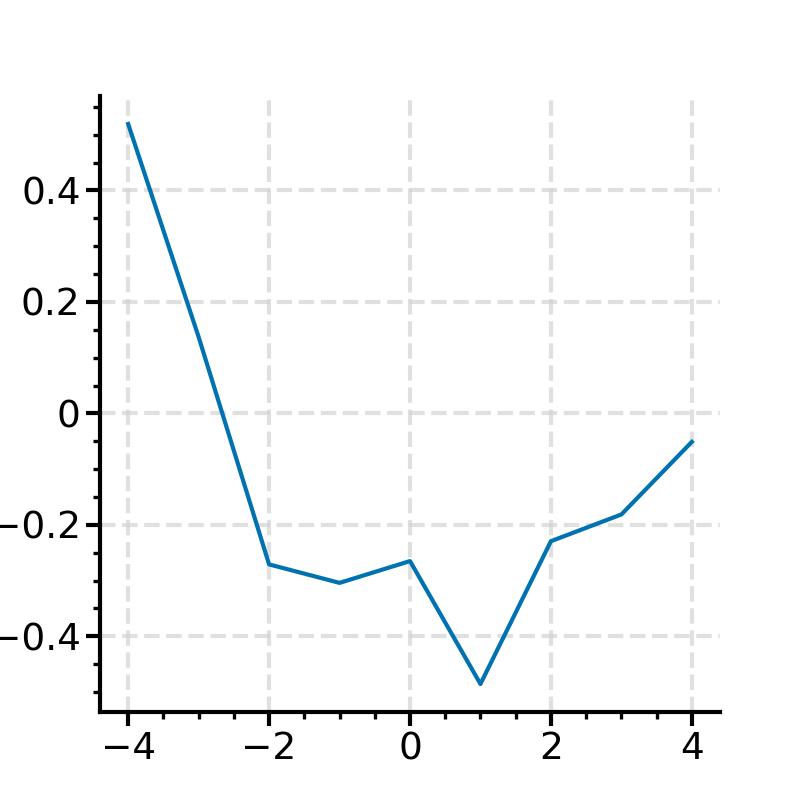

In [69]:
plt.plot(lags[0],np.array(lagcorrs)[-2,:])
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_88006/3155803825.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


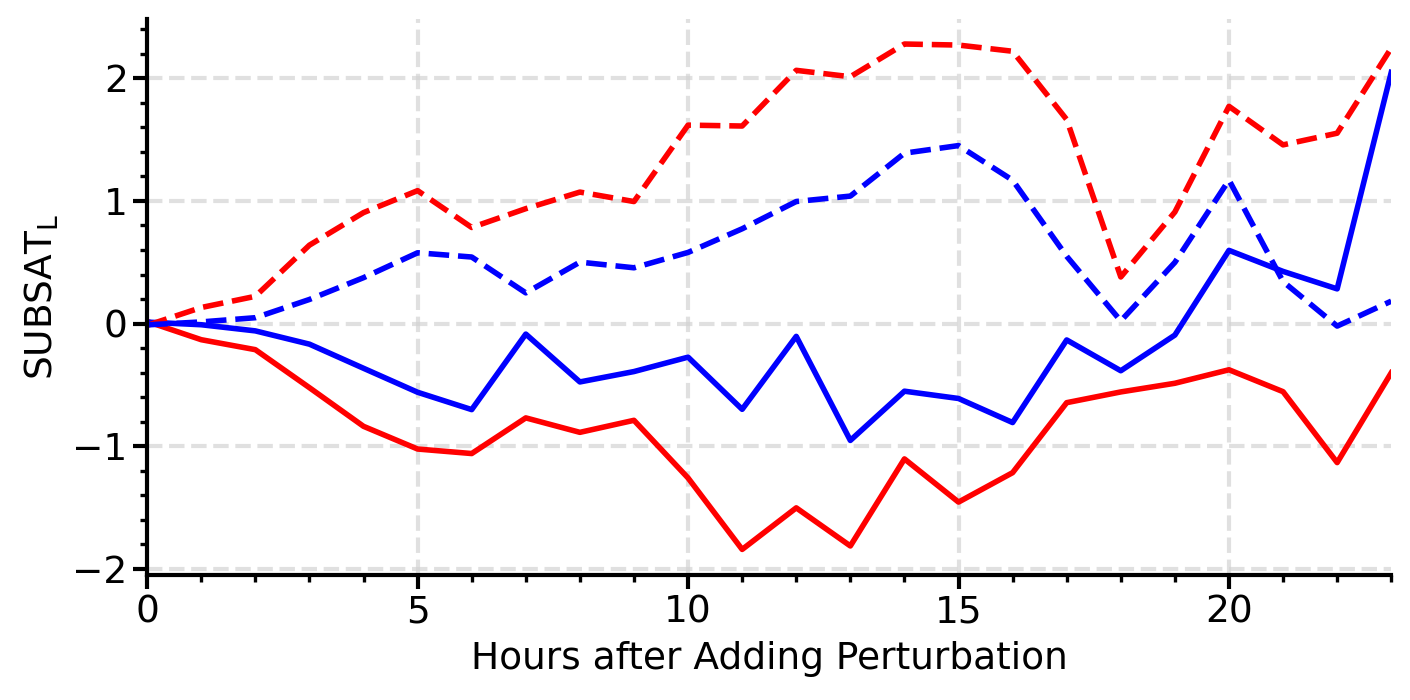

In [46]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
#am = axs[0].plot(np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
#                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(subsatl_dict['DD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(subsatl_dict['AIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(subsatl_dict['MDD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(subsatl_dict['MIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(subsatl_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
#axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='SUBSAT$_{L}$')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()

/glade/derecho/scratch/ihtam/tmp/ipykernel_88006/559830309.py:15: ProplotWarning: fig.tight_layout() has no effect on proplot figures. Proplot uses its own tight layout algorithm that is activated by default. To disable it, set pplt.rc['subplots.tight'] to False or pass tight=False to pplt.subplots(). For details, see fig.auto_layout().
  plt.tight_layout()


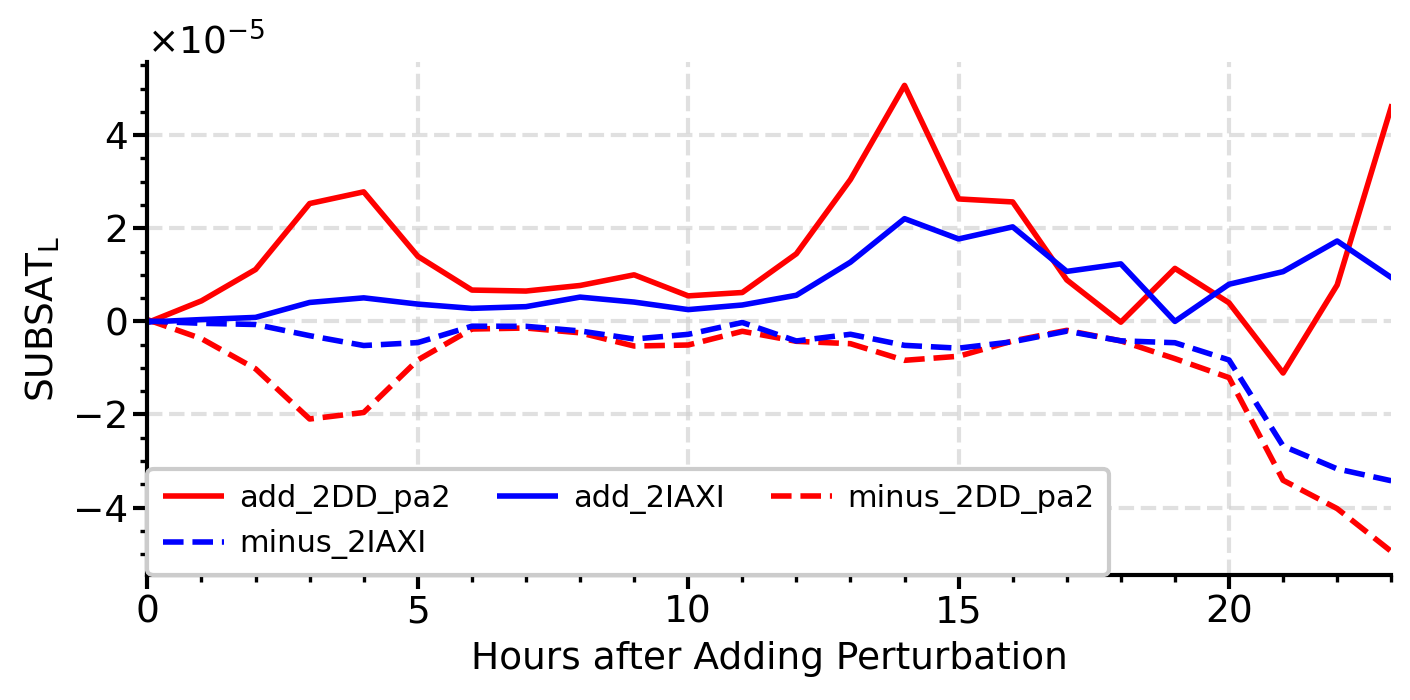

In [47]:
fig, axs = plot.subplots(ncols=1, nrows=1, figsize=(7.05,3.5), share=True)
#am = axs[0].plot(np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
#                 c='k', lw=2, label='CTRL')
am = axs[0].plot(np.nanmean(hdia_pw_dict['DD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='add_2DD_pa2')
am = axs[0].plot(np.nanmean(hdia_pw_dict['AIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='add_2IAXI')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MDD_P2F'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='r', lw=2, label='minus_2DD_pa2', ls='--')
am = axs[0].plot(np.nanmean(hdia_pw_dict['MIAXI2X'][:,:33,:],axis=(1,2))-np.nanmean(hdia_pw_dict['CTRL'][:,:33,:],axis=(1,2)), 
                 c='b', lw=2, label='minus_2IAXI', ls='--')
axs[0].legend(ncols=3,loc=1)
axs.format(#ylim=(1000,100),
           xlabel='Hours after Adding Perturbation', ylabel='SUBSAT$_{L}$')
plt.tight_layout()
#plt.savefig('./pics/subsatl_wrfmemb03.png',dpi=400)
plt.show()